In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns

# plotting
import matplotlib.pyplot as plt
%matplotlib inline

# settings
plt.style.use('seaborn')
plt.rcParams["figure.figsize"] = (15, 5)

# Background

### About

Booking.com’s mission is to make it easier for everyone to experience the world. By investing in the technology that helps take the friction out of travel, Booking.com seamlessly connects millions of travellers with memorable experiences, a range of transport options and incredible places to stay.

Many of the travellers go on trips which include more than one destination. For instance, a user from the US could fly to Amsterdam for 5 nights, then spend 2 nights in Brussels, 3 in Paris and 1 in Amsterdam again before heading back home. In this scenario, we suggest options for extending their trip immediately when they make their booking.

The goal of this challenge is to use a dataset based on millions of real anonymized accommodation reservations to come up with a strategy for making the best recommendation for their next destination.
Booking.com releases this unique dataset to encourage the research on sequential recommendation problems.
### Evaluation criteria

The goal of the challenge is to predict (and recommend) the final city (city_id) of each trip (utrip_id). We will evaluate the quality of the predictions based on the top four recommended cities for each trip by using Top-4 Accuracy metric (4 representing the four suggestion slots at Booking.com website). When the true city is one of the top 4 suggestions (regardless of the order), it is considered correct.

# Data analysis - Train data

### Data Description

**user_id** - User ID   
**check-in** - Reservation check-in date   
**checkout** - Reservation check-out date   
**affiliate_id** - An anonymized ID of affiliate channels where the booker came from (e.g. direct, some third party referrals, paid search engine, etc.)   
**device_class** - desktop/mobile   
**booker_country** - Country from which the reservation was made (anonymized)   
**hotel_country** - Country of the hotel (anonymized)   
**city_id** - city_id of the hotel’s city (anonymized)   
**utrip_id** - Unique identification of user’s trip (a group of multi-destinations bookings within the same trip)

Each reservation is a part of a customer’s trip (identified by utrip_id) which includes ~~at least 4~~ consecutive reservations. There are 0 or more days between check-out and check-in dates of two consecutive reservations.

**Note: The atleast 4 criteria seems to have been changed recently, as the data is not like that**

The evaluation dataset is constructed similarly, however the city_id of the final reservation of each trip is concealed and requires a prediction.

In [3]:
df = pd.read_csv('../../datasets/booking/booking_train_set.csv.gz')

In [4]:
df.head()

,Unnamed: 0,user_id,checkin,checkout,city_id,device_class,affiliate_id,booker_country,hotel_country,utrip_id
0,0,1006220,2016-04-09,2016-04-11,31114,desktop,384,Gondal,Gondal,1006220_1
1,1,1006220,2016-04-11,2016-04-12,39641,desktop,384,Gondal,Gondal,1006220_1
2,2,1006220,2016-04-12,2016-04-16,20232,desktop,384,Gondal,Glubbdubdrib,1006220_1
3,3,1006220,2016-04-16,2016-04-17,24144,desktop,384,Gondal,Gondal,1006220_1
4,4,1010293,2016-07-09,2016-07-10,5325,mobile,359,The Devilfire Empire,Cobra Island,1010293_1


There's an unnamed column. Let's remove that

In [5]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [6]:
df.shape

(1166835, 9)

In [7]:
df.dtypes

user_id            int64
checkin           object
checkout          object
city_id            int64
device_class      object
affiliate_id       int64
booker_country    object
hotel_country     object
utrip_id          object
dtype: object

In [8]:
# check for missing values
df.isnull().sum()

user_id           0
checkin           0
checkout          0
city_id           0
device_class      0
affiliate_id      0
booker_country    0
hotel_country     0
utrip_id          0
dtype: int64

No missing values. Yipee

In [9]:
# convert int types to str as they are categorical values
df['user_id'] = df['user_id'].apply(lambda x: str(x))
df['city_id'] = df['city_id'].apply(lambda x: str(x))
df['affiliate_id'] = df['affiliate_id'].apply(lambda x: str(x))

In [11]:
df.describe()

,user_id,checkin,checkout,city_id,device_class,affiliate_id,booker_country,hotel_country,utrip_id
count,1166835,1166835,1166835,1166835,1166835,1166835,1166835,1166835,1166835
unique,200153,425,425,39901,3,3254,5,195,217686
top,2209265,2016-08-08,2016-08-10,47499,desktop,9924,Gondal,Cobra Island,3635431_3
freq,172,9672,9549,11242,753860,277775,536036,137791,48


In [12]:
col_count = df.describe().iloc[:2,:].transpose()
col_count['count_per_unique'] = col_count['count']/col_count['unique']

In [13]:
col_count

,count,unique,count_per_unique
user_id,1166835,200153,5.82972
checkin,1166835,425,2745.49
checkout,1166835,425,2745.49
city_id,1166835,39901,29.2433
device_class,1166835,3,388945
affiliate_id,1166835,3254,358.585
booker_country,1166835,5,233367
hotel_country,1166835,195,5983.77
utrip_id,1166835,217686,5.36017


Obs:  
1. 200k users making 1.16 million stays. **This is 5.8 stays on averge per user**
2. 425 days or 14 months of data. Further analysis later on
3. Almost 40k cities. 30 stays on average each city
4. 3 kinds of device used - Mobile, desktop and what is the 3rd?
5. Booker come from 3k different sources
6. Data covers users from 5 countries (anonymised) and they book hotel in 195 countries (virtually all the countries that are there on this earth)
7. The number of the trips is slighlty more than the number of users. **So most users seemed to have just made 1 trip, and few (217686-200153=17533) seems to have made more than 1. Average number of stays per trip is (1166835/217686 = 5.36)**
8. Number of stays per trip is around 5.36

## Time analysis

#### Date ranges

In [14]:
# convert to datetime
df['checkin'] = pd.to_datetime(df['checkin'])
df['checkout'] = pd.to_datetime(df['checkout'])

In [15]:
print ('Checkin date range:',df['checkin'].min(),df['checkin'].max())
print ('Checkout date range:',df['checkout'].min(),df['checkout'].max())

Checkin date range: 2015-12-31 00:00:00 2017-02-27 00:00:00
Checkout date range: 2016-01-01 00:00:00 2017-02-28 00:00:00


#### Stay time frequency

In [16]:
df['stay'] = (df['checkout']-df['checkin']).dt.days

In [17]:
df['stay'].max()

30

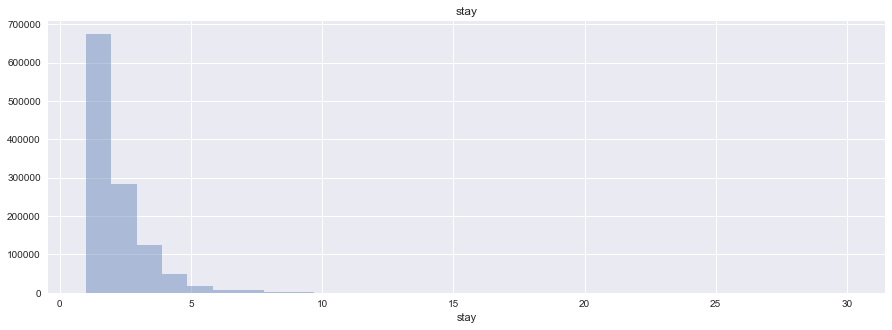

In [18]:
plt.figure()
plt.title('stay')
ax = sns.distplot(df['stay'],bins=30,kde=False)
plt.show()

Obs: Most stays last till 5 days. Max is 30 days

In [19]:
df['stay'].mean()

1.739171348134055

Each stay is aroung 1.73 days

#### Count of stays by checkin and checkout dates

<AxesSubplot:>

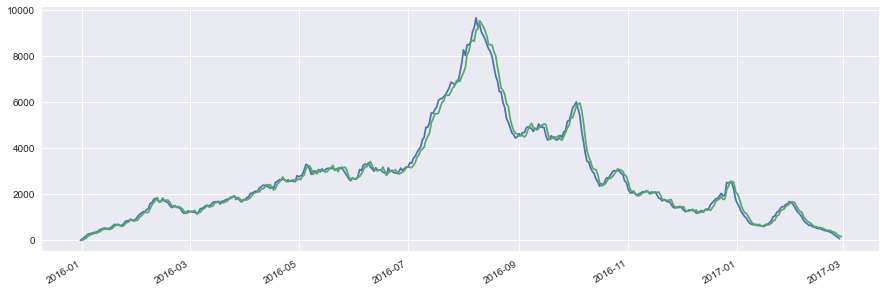

In [20]:
df['checkin'].value_counts().plot()
df['checkout'].value_counts().plot()

Obs: There are some peak in number of stays. Though we should take this in the context that this for trips that have atleast 4 stays

## Frequency analysis

We check how the count of stays by each column are distributed. This would give us an idea of how many data points we have for each of the catergories in these columns - in fact the distribution of that

In [21]:
df.columns

Index(['user_id', 'checkin', 'checkout', 'city_id', 'device_class',
       'affiliate_id', 'booker_country', 'hotel_country', 'utrip_id', 'stay'],
      dtype='object')

{'min value': 1, 'max value': 172}


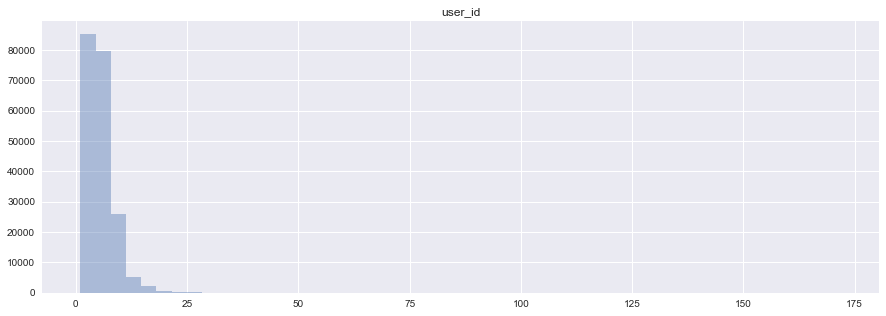

{'min value': 1, 'max value': 11242}


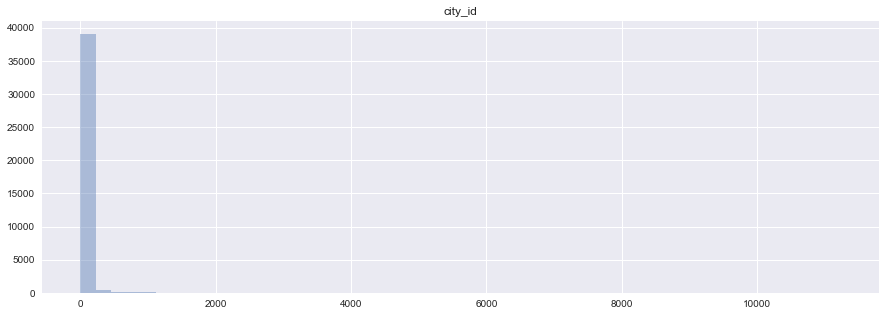

{'min value': 1, 'max value': 277775}


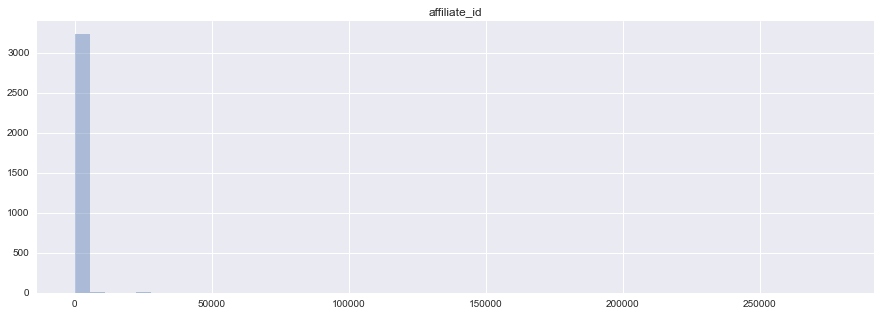

{'min value': 1, 'max value': 137791}


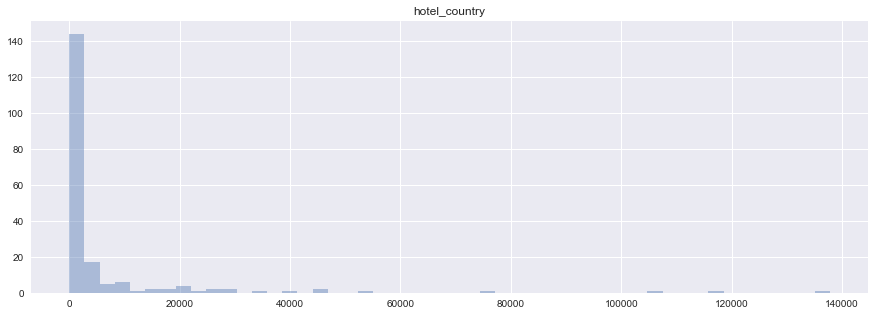

{'min value': 1, 'max value': 48}


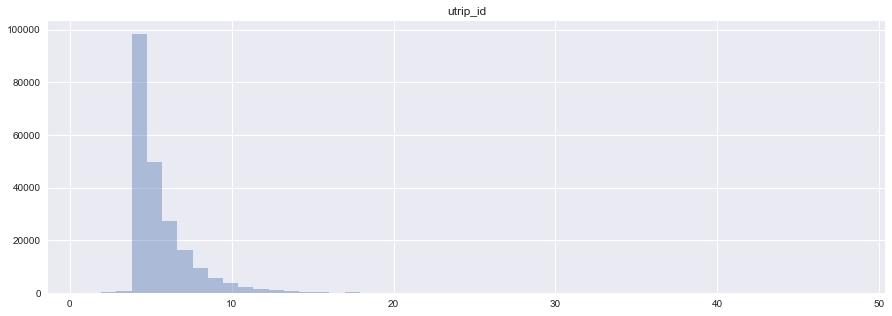

In [22]:
for col in ['user_id','city_id','affiliate_id','hotel_country','utrip_id']:
    plt.figure()
    plt.title(col)
    ax = sns.distplot(pd.DataFrame(df[col].value_counts()),kde=False)
    print ({'min value':df[col].value_counts().min(),
            'max value':df[col].value_counts().max()})
    plt.show()

1. user_id: Number of stays in 14 months mostly remain less than 20. Someone has 175'ish stays. Looks cooky
2. city_id: Maximum stays in a city seems to be 1000'ish
3. affiliate_id: The maximum stays from an affiliate_id seems to be 250k
4. hotel_country: The maximum stays in a country are 140k
5. The maximum stays in a trip seems to go up till 48. Wow. That's something

# Popularity Bias

If we look at the frequency plot for city_ids, we see that some city are more common than others. This is called popularity bias and is quite common

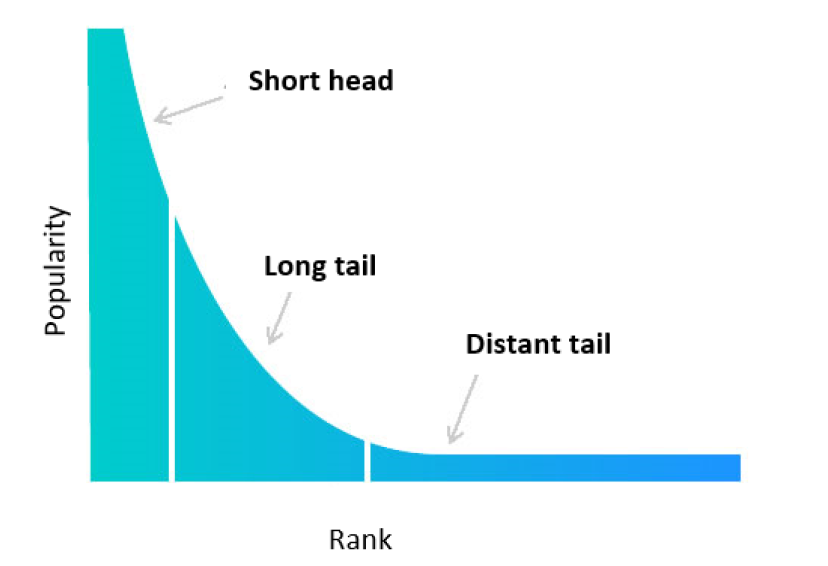

In [27]:
df['city_id'].value_counts()

47499    11242
23921    10511
36063     9559
17013     9011
29319     8179
         ...  
4000         1
20771        1
32937        1
65763        1
46905        1
Name: city_id, Length: 39901, dtype: int64

In [35]:
(df['city_id'].value_counts()<=10).sum()/len(df['city_id'].value_counts())

0.7775744968797774

In [34]:
(df['city_id'].value_counts()<=10).sum()

31026

In [30]:
len(df['city_id'].value_counts())

39901

# Data Analysis - Test Data

In [16]:
df_test = pd.read_csv('../../datasets/booking/booking_test_set.csv.gz')

In [17]:
df_test.head()

,user_id,checkin,checkout,device_class,affiliate_id,booker_country,utrip_id,row_num,total_rows,city_id,hotel_country
0,1000066,2016-07-21,2016-07-23,desktop,9924,Gondal,1000066_2,1,4,56430,Urkesh
1,1000066,2016-07-23,2016-07-25,desktop,9924,Gondal,1000066_2,2,4,41971,Urkesh
2,1000066,2016-07-25,2016-07-28,desktop,9924,Gondal,1000066_2,3,4,5797,Urkesh
3,1000066,2016-07-28,2016-07-31,mobile,2436,Gondal,1000066_2,4,4,0,NaN
4,1000270,2016-02-08,2016-02-09,mobile,9452,The Devilfire Empire,1000270_1,1,4,50075,The Devilfire Empire


## 1. Compare user_id, utrip_id and city_id in train and test datasets

#### user_id

In [18]:
intersect = set(df['user_id']) & set(df_test['user_id'])
diff = set(df['user_id']) - set(df_test['user_id'])

In [19]:
print ('Train: {}, Test:{}'.format(len(df['user_id'].unique()),len(df_test['user_id'].unique())))
print ('Intersecting ids: {}, Different ids: {}'.format(len(intersect),len(diff)))

Train: 200153, Test:68502
Intersecting ids: 0, Different ids: 200153


#### utrip_id

In [20]:
intersect = set(df['utrip_id']) & set(df_test['utrip_id'])
diff = set(df['utrip_id']) - set(df_test['utrip_id'])

In [21]:
print ('Train: {}, Test:{}'.format(len(df['utrip_id'].unique()),len(df_test['utrip_id'].unique())))
print ('Intersecting ids: {}, Different ids: {}'.format(len(intersect),len(diff)))

Train: 217686, Test:70662
Intersecting ids: 0, Different ids: 217686


This is a given since each trip is unique

#### city_id

In [22]:
intersect = set(df['city_id']) & set(df_test['city_id'])
diff = set(df['city_id']) - set(df_test['city_id'])

In [23]:
print ('Train: {}, Test:{}'.format(len(df['city_id'].unique()),len(df_test['city_id'].unique())))
print ('Intersecting ids: {}, Different ids: {}'.format(len(intersect),len(diff)))

Train: 39901, Test:21305
Intersecting ids: 0, Different ids: 39901


All city_ids that are part of test are also part of train, except just 1

## 2. Compare the time

In [26]:
print (df['checkin'].min(), df['checkin'].max())
print (df_test['checkin'].min(), df_test['checkin'].max())

2015-12-31 00:00:00 2017-02-27 00:00:00
2015-12-31 2017-02-27


Time aware splitting has not been done. Interesting